# 🧠 Modern CNN Architectures: From Classic to SOTA

> **Course: Computer Vision — Advanced Module**  
> **Topics:** Top CNN Architectures · Object Detection · Attention Mechanisms · Transfer Learning

---

This notebook provides a deep dive into the **state-of-the-art convolutional neural network (CNN) architectures** and key trends in modern computer vision. Each section combines theory with working PyTorch code.

## 📋 Table of Contents
0. [Environment Setup](#setup)
1. [New concepts](#new-concepts)
   - Activation Functions
   - Batch Normalization 
   - Layer Normalization
   - Group Normalization
   - Depthwise + pointwise
1. [Top Performing CNN Architectures](#top-cnns)
   - ConvNeXt & ConvNeXt V2
   - Global Response Normalization (GRN)
   - EfficientNetV2
   - NFNet (NormFree Networks)
   - ResNeXt & Wide Residual Networks
3. [SOTA Object Detection & Segmentation](#detection)
   - YOLO Series
   - Mask R-CNN / Faster R-CNN
   - EfficientDet
4. [Key Trends & Characteristics](#trends)
   - Attention Mechanisms (SE, CBAM)
   - Efficiency vs Performance
   - Transfer Learning

---

<a id='setup'></a>
## ⚙️ 0. Environment Setup

In [1]:
# Install required libraries
!uv pip install torch torchvision timm matplotlib torchinfo hjson --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import timm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from torchinfo import summary
from collections import OrderedDict

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🔧 PyTorch version : {torch.__version__}')
print(f'🔧 Torchvision     : {torchvision.__version__}')
print(f'🔧 TIMM version    : {timm.__version__}')
print(f'🖥️  Device          : {device}')

🔧 PyTorch version : 2.11.0
🔧 Torchvision     : 0.26.0
🔧 TIMM version    : 1.0.26
🖥️  Device          : cpu


<a id='new-concepts'></a>

## New Concepts
We are introducing new concepts to discuss state-of-the-art CNN architectures.

### 1. Normalization Layers

#### 1.1 *Internal Covariate Shift*
It's the problem that BatchNorm was invented to solve.

#### *The intuition*
Imagine you're training layer 5 of a deep network. Layer 5 learns to transform its inputs in a useful way. But layer 4 is also learning and changing its weights — which means the distribution of inputs arriving at layer 5 keeps shifting during training.
<p>
Layer 5 is essentially trying to hit a moving target. Example : 
</p>

```text
Epoch 1:   Layer 4 outputs  →  mean≈0.5,  std≈1.2  → Layer 5 adapts
Epoch 2:   Layer 4 outputs  →  mean≈1.8,  std≈0.4  → Layer 5 has to re-adapt
Epoch 3:   Layer 4 outputs  →  mean≈-0.3, std≈2.1  → Layer 5 has to re-adapt again
              ↑
         This constant distribution shift = Internal Covariate Shift
```

<p>
<img src="content/internal-cov-shift.webp">
</p>
The word "covariate" comes from statistics — it just means input features. "Internal" means it's happening inside the network, between layers, not just at the input.

#### *Why it's a problem*

1. Slows down training
Each layer wastes capacity constantly readjusting to the new input distribution instead of learning the actual task.
2. Requires very small learning rates
Large learning rates cause big weight updates → big distribution shifts → downstream layers destabilize → gradients explode or vanish.
3. Saturating activations
If inputs drift into the saturation zone of sigmoid or tanh, gradients become nearly zero

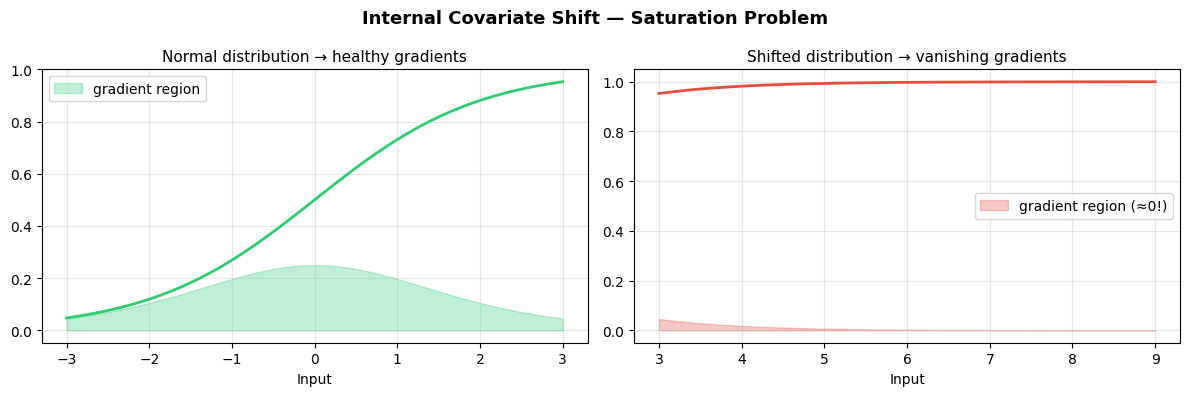

In [3]:
x_normal = torch.linspace(-3, 3, 100)    # well-distributed inputs
x_shifted = torch.linspace(3, 9, 100)    # shifted inputs (covariate shift)

sigmoid = torch.sigmoid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_normal, sigmoid(x_normal), color='#2ecc71', linewidth=2)
axes[0].fill_between(x_normal, 0,
                     sigmoid(x_normal) * (1 - sigmoid(x_normal)),
                     alpha=0.3, color='#2ecc71', label='gradient region')
axes[0].set_title('Normal distribution → healthy gradients', fontsize=11)
axes[0].set_xlabel('Input'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_shifted, sigmoid(x_shifted), color='#e74c3c', linewidth=2)
axes[1].fill_between(x_shifted, 0,
                     sigmoid(x_shifted) * (1 - sigmoid(x_shifted)),
                     alpha=0.3, color='#e74c3c', label='gradient region (≈0!)')
axes[1].set_title('Shifted distribution → vanishing gradients', fontsize=11)
axes[1].set_xlabel('Input'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Internal Covariate Shift — Saturation Problem', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 Batch Normalization


**Batch normalization** is a technique used in training neural networks to stabilize and speed up learning by normalizing the inputs of each layer.

#### How it works

For each mini-batch during training:

1. Compute the mean and variance of the layer’s inputs:
<p>
<img src="content/norm-layer.png">
</p>

2. Normalize the inputs:
<p>
<img src="content/normalization.png">
</p>
3. Apply learnable scaling and shifting:
<p>
<img src="content/norm-linear.png">
</p>

* **μ (mean)** and **σ² (variance)** come from the batch
* **ε** is a small constant for numerical stability
* **γ (gamma)** and **β (beta)** are learned parameters

#### Why it’s useful

* Reduces internal covariate shift (inputs changing distribution during training)
* Allows higher learning rates
* Speeds up convergence
* Acts as a regularizer (can reduce need for dropout)

#### During inference

Instead of batch statistics, it uses **running averages** of mean and variance computed during training.

#### Where it’s used

* Common in CNNs and deep networks
* Typically placed **after linear/conv layers and before activation**

#### Intuition

It keeps activations in a stable range, preventing layers from constantly adapting to shifting input distributions.
#### Problems:

- ❌ Needs a large enough batch to compute stable statistics
- ❌ Training vs inference discrepancy (running mean/var)
- ❌ Complicated in distributed training (sync across GPUs)
- ❌ Doesn't work with batch size = 1


<a id='activation-functions'></a>
### 1.3 Layer Normalization 

Layer normalization is a normalization technique used in neural networks that normalizes the activations across the features of a single sample, instead of across a batch.



| Aspect                         | Batch Normalization    | Layer Normalization          |
| ------------------------------ | ---------------------- | ---------------------------- |
| Normalization over             | Batch (across samples) | Features (within one sample) |
| Depends on batch size          | Yes                    | No                           |
| Works well with                | CNNs                   | RNNs, Transformers           |
| Training vs inference behavior | Different              | Same                         |


```text
B0    B1    B2    B3
C0      [ x     x     x     x ]   ← BatchNorm normalizes down this column
C1      [ x     x     x     x ]      (across the batch dimension)
C2      [ x     x     x     x ]
C3      [ x     x     x     x ]
          ↑
        LayerNorm normalizes across this row
        (across the channel dimension, per sample)
```

### 1.4 Group Normalization

**Group Normalization** (GN), introduced by [Wu & He (2018)](https://arxiv.org/pdf/1803.08494), is a normalization layer meant as a **batch-size–agnostic** alternative to Batch Normalization. Where BN aggregates statistics over the **batch** (and spatial locations), GN **never uses the batch dimension**: it partitions channels into **G groups** and normalizes using the mean and variance computed **within each group**, over that group’s channels and spatial positions **(H × W)** for a single sample.

#### Motivation (from the paper)

- BN’s estimated batch mean and variance become **noisy when the mini-batch is small**, which hurts accuracy; this matters for **detection, segmentation, and video**, where memory often forces small batches.
- GN’s computation is **independent of batch size**, so training behaves similarly for batch size 2 or 32.
- On **ImageNet with ResNet-50**, GN had about **10.6% lower top-1 error than BN when the batch size was 2**; with **typical large batches**, GN was **comparable to BN** and **better than other normalization variants** tested in that setting.
- GN **transfers cleanly** from pre-training to fine-tuning and worked well on **COCO** (detection/segmentation) and **Kinetics** (video) in their experiments.

#### How it differs from BN and Layer Norm

| Method | Main axes used for μ, σ² (per channel group / sample) | Uses batch? |
|--------|--------------------------------------------------------|-------------|
| **Batch Norm** | N × H × W (per channel) | Yes |
| **Layer Norm** | C × H × W (per sample) | No |
| **Group Norm** | (C/G) × H × W **per group**, per sample | No |

Like BN, GN still applies **learnable scale γ and shift β** after normalizing, so the layer can undo normalization if the network needs it.

#### Practical notes

- **Hyperparameter G**: the number of groups must divide the channel count **C**. A common default in the paper and in libraries is **G = 32** when **C** is divisible by 32.
- **PyTorch**: `nn.GroupNorm(num_groups, num_channels)` — same API at train and inference (no running buffers like BN).

#### Illustration (grouped channels per normalization region)

<p>
<img src="content/group-norm.png">
</p>

**Reference:** Yuxin Wu & Kaiming He, *Group Normalization*, ECCV 2018 / [arXiv:1803.08494](https://arxiv.org/pdf/1803.08494).

### 1.5 Summary of Normalization Layers

*This is a quote from the paper section 3.1*
<p>
This means that the pixels sharing the same
channel index are normalized together, i.e., for each channel, BN computes µ and σ along the (N, H, W) axes. In
Layer Norm [3], the set is:
</p>

```
Si = {k | kC = iC }
```

<p>
where iC (and kC ) denotes the sub-index of i (and k) along
the C axis. This means that the pixels sharing the same
channel index are normalized together, i.e., for each channel, BN computes µ and σ along the (N, H, W) axes.
</p>
In Layer Norm [3], the set is:

```
Si = {k | kN = iN }, 
```

<p>
meaning that LN computes µ and σ along the (C, H, W)
axes for each sample. In Instance Norm [61], the set is:
</p>

```
Si = {k | kN = iN , kC = iC }. 
```

meaning that IN computes µ and σ along the (H, W) axes
for each sample and each channel



<p>
<img src="content/normalizations-draw.png">
</p>


### 1.5 Depthwise + Pointwise convolutions
**Depthwise convolution** is a variant of standard convolution used in CNNs that processes each input channel **independently**, instead of mixing all channels together.

---

#### Standard Convolution (baseline)

In a normal convolution:

* Input: H×W×C
* Filters:K×K×C
* Each filter spans **all channels**
* Output channels = number of filters

👉 Each filter mixes spatial + cross-channel information at once.

<p>
<img src="content/std-conv.webp">
</p>

---

#### Depthwise Convolution 

In **depthwise convolution**:

* You use **one filter per input channel**
* Each filter is K×K×1
* No mixing between channels

If input has (C) channels:

* You apply **C separate filters**
* Output also has (C) channels


---

#### How it works (step-by-step)

For an input with 3 channels (RGB):

* Apply 1 filter to Red channel
* Apply 1 filter to Green channel
* Apply 1 filter to Blue channel

Each channel is convolved **independently**.


---

#### Depthwise Separable Convolution

Depthwise is usually **not used alone**.

It’s combined with:

* **Depthwise convolution** → spatial filtering
* **Pointwise (1×1) convolution** → channel mixing

This combination is called:
👉 **Depthwise Separable Convolution**

<p>
<img src="content/depthwise.webp">
</p>


Used in:

* MobileNet
* EfficientNet
* Xception

---

#### Why it matters

#### Advantages

* Much **fewer parameters**
* Lower **compute cost (FLOPs)**
* Ideal for:

  * Mobile devices
  * Edge AI
  * Real-time inference

#### Trade-off

* Slightly less expressive than full convolution
* Needs pointwise conv to recover performance

---

#### Intuition (simple analogy)

* Standard convolution = mixing all colors while painting
* Depthwise = painting each color separately
* Pointwise = blending colors afterward

---

#### Summary

| Feature        | Standard Conv         | Depthwise Conv        |
| -------------- | --------------------- | --------------------- |
| Channel mixing | Yes                   | No                    |
| Filters        | K x K x C             | K x K x 1             |
| Cost           | High                  | Low                   |
| Use alone      | Yes                   | Rare                  |
| Typical usage  | General CNNs          | Efficient CNNs        |

---

If needed, can show PyTorch / TensorFlow implementation or compare with grouped convolution (closely related concept).


In [4]:


C = 96   # channels

# Standard conv: every output channel sees ALL input channels
standard_conv = nn.Conv2d(
    in_channels  = C,
    out_channels = C,
    kernel_size  = 7,
    padding      = 3,
    # groups       = 1     # default — all channels connected
)

# Depthwise conv: each output channel sees ONLY its own input channel
depthwise_conv = nn.Conv2d(
    in_channels  = C,
    out_channels = C,
    kernel_size  = 7,
    padding      = 3,
    groups       = C     # ← groups=C makes it depthwise
)

x   = torch.randn(3, C, 56, 56)
out = depthwise_conv(x)
out_std = standard_conv(x)

print(f'Input  : {x.shape}')
print(f'Output : {out.shape}')   # same shape — only spatial mixing
print(f'Output standard conv: {out_std.shape}')   # same shape — only spatial mixing
# Parameter comparison
std_params = sum(p.numel() for p in standard_conv.parameters())
dw_params  = sum(p.numel() for p in depthwise_conv.parameters())

print(f'\nStandard Conv params : {std_params:,}')
print(f'Depthwise Conv params: {dw_params:,}')
print(f'Reduction factor     : {std_params / dw_params:.0f}×')


Input  : torch.Size([3, 96, 56, 56])
Output : torch.Size([3, 96, 56, 56])
Output standard conv: torch.Size([3, 96, 56, 56])

Standard Conv params : 451,680
Depthwise Conv params: 4,800
Reduction factor     : 94×


---
<a id='top-cnns'></a>
# 🏆 2. Top Performing CNN Architectures

The landscape of CNN architectures has evolved dramatically. These modern designs borrow heavily from the success of **Vision Transformers (ViTs)** while maintaining the computational efficiency of convolutional operations.
## 2.1 ConvNeXt & ConvNeXt V2

<p>
<img src="content/convexnet.jpeg">
</p>

**ConvNeXt** (Liu et al., 2022 — Meta AI) is a modernized ResNet that systematically adopted every successful design decision from Vision Transformers:

### 🔑 Key Innovation: The ConvNeXt Block

| Design Choice | ResNet | ViT (Vision Transformers )| ConvNeXt |
|---|---|---|---|
| Patch Size | No Patch - 2×1 stride | 16×16 non-overlap | 4×4 non-overlap |
| Activation | ReLU | GELU | **GELU** |
| Normalization | BatchNorm | LayerNorm | **LayerNorm** |
| Convolution | 3×3 | Attention | **7×7 Depthwise** |
| Stage ratio | (3,4,6,3) | - | **(3,3,9,3)** |



## 2.2 ConvNeXt V2 - Global Response Normalization (GRN)

---
**ConvNeXt V2** (Woo et al., 2023) added **Global Response Normalization (GRN)** — a layer that suppresses redundant feature activations, further closing the gap with masked autoencoders.
**GRN** stands for **Global Response Normalization**.

It is a normalization technique introduced in **ConvNeXt V2** to improve how feature maps are scaled and balanced across channels.

---

#### Core idea

GRN normalizes features based on their **global (spatial) response**, and then **recalibrates channels to compete with each other**.

<p>
<img src="content/convnextv2.png" width="500" heigh="500">
</p>

#### Why GRN is useful :

1. Encourages channel competition

- Strong channels don’t dominate
- Weak channels get boosted


2. Prevents feature collapse

- Especially important in **self-supervised learning**
- Keeps representations diverse


3. Works well with vision tasks

- Captures **global context**
- Improves robustness and generalization

---

#### GRN vs other normalizations

| Method       | Normalizes over       | Key effect                      |
| ------------ | --------------------- | ------------------------------- |
| BatchNorm    | Batch                 | Stabilizes training             |
| LayerNorm    | Channels              | Transformer-style normalization |
| InstanceNorm | Spatial (per channel) | Style invariance                |
| **GRN**      | Global + channels     | Channel competition             |



**GRN = normalize global channel strength and use it to rebalance feature maps dynamically.**



In [5]:
class ConvNeXtBlock(nn.Module):
    """
    ConvNeXt Block — the core building unit.
    
    Key design choices vs classic ResNet block:
      • 7×7 depthwise conv  (large receptive field, like self-attention)
      • Inverted bottleneck  (expand → GELU → compress)
      • LayerNorm instead of BatchNorm
      • GELU instead of ReLU
      • Fewer activations / normalizations in the block
    """
    def __init__(self, dim: int, layer_scale: float = 1e-6):
        super().__init__()
        self.block = nn.Sequential(
            # Step 1: Depthwise 7×7 conv (spatial mixing per channel)
            nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim),
            # Step 2: Permute to (B, H, W, C) for LayerNorm on channel dim
        )
        self.norm  = nn.LayerNorm(dim, eps=1e-6)
        # Step 3: Inverted bottleneck with pointwise (linear) layers
        self.pwconv1 = nn.Linear(dim, 4 * dim)    # expand
        self.act     = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)    # compress
        # Learnable per-channel scale (improves training stability)
        self.gamma = nn.Parameter(
            layer_scale * torch.ones(dim), requires_grad=True
        ) if layer_scale > 0 else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.block(x)                         # (B, C, H, W)
        x = x.permute(0, 2, 3, 1)                # → (B, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2)                # → (B, C, H, W)
        return residual + x                        # Residual connection


# ── Quick test ──────────────────────────────────────────────────────────────
block = ConvNeXtBlock(dim=96).to(device)
x     = torch.randn(3, 96, 56, 56).to(device)    # (Batch=2, C=96, H=56, W=56)
out   = block(x)

print(f'ConvNeXt Block')
print(f'  Input  shape : {x.shape}')
print(f'  Output shape : {out.shape}')
params = sum(p.numel() for p in block.parameters())
print(f'  Parameters   : {params:,}')

ConvNeXt Block
  Input  shape : torch.Size([3, 96, 56, 56])
  Output shape : torch.Size([3, 96, 56, 56])
  Parameters   : 79,296


In [6]:
# ── Load pretrained ConvNeXt via timm ────────────────────────────────────────
# timm has the full model family: tiny, small, base, large, xlarge
convnext = timm.create_model('convnext_xlarge', pretrained=False, num_classes=10)

print('=== ConvNeXt-XLarge Architecture (timm) ===')
print(f'Model stages: {[name for name, _ in convnext.named_children()]}')

# Parameter count per stage
total = 0
print('\n📊 Parameters per stage:')
for name, module in convnext.named_children():
    stage_params = sum(p.numel() for p in module.parameters())
    total += stage_params
    print(f'  {name:<20} → {stage_params:>8,} params')
print(f'  {"TOTAL":<20} → {total:>8,} params')

# Forward pass
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    logits = convnext(dummy)
print(f'\n✅ Output logits shape: {logits.shape}  (batch=1, num_classes=10)')

=== ConvNeXt-XLarge Architecture (timm) ===
Model stages: ['stem', 'stages', 'norm_pre', 'head']

📊 Parameters per stage:
  stem                 →   13,056 params
  stages               → 348,130,816 params
  norm_pre             →        0 params
  head                 →   24,586 params
  TOTAL                → 348,168,458 params

✅ Output logits shape: torch.Size([1, 10])  (batch=1, num_classes=10)


## 2.3 Testing a pretrained `convnext_xlarge` on ImageNet-1k.
We are downloading a smaller version of the ImageNet dataset. Since the pre-trained model was trained on the original ImageNet-1k, we need to use the original label mapping rather than the labels inferred from this dataset’s directory structure (one folder per class).

*Q 2.3.0*: Why? What's happened with the Head of the model ? 


In [7]:
! mkdir -p ./data 
! [ -f ./data/imagenet-256.zip ] || curl -L -o ./data/imagenet-256.zip https://www.kaggle.com/api/v1/datasets/download/dimensi0n/imagenet-256
! [ -d ./data/imagenet-256 ] || unzip -q ./data/imagenet-256.zip -d ./data/imagenet-256
! curl https://gist.githubusercontent.com/yrevar/942d3a0ac09ec9e5eb3a/raw/238f720ff059c1f82f368259d1ca4ffa5dd8f9f5/imagenet1000_clsidx_to_labels.txt > ./data/imagenet-256/clsidx.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 30564  100 30564    0     0  64005      0 --:--:-- --:--:-- --:--:-- 63941


### 2.3.1 - Load Dataset

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms
import hjson
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

ROOT = './data/imagenet-256'   # folder containing train/ and val/
CLASSES = hjson.load(open(f'{ROOT}/clsidx.json'))
BATCH_SIZE = 30

val_transform = transforms.Compose([
    transforms.CenterCrop(224),             # center 224 crop from 256
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

val_dataset = ImageFolder(
    root      = f'{ROOT}/',
    transform = val_transform
)

print(f'Val samples   : {len(val_dataset):,}')
print(f'First 5 classes: {val_dataset.classes[:5]}')
print(f'Original classes: {[ c.split(',')[0] for c in CLASSES.values()][:5]}')
print(f'Total classes : {len(val_dataset.classes)}')

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 8,
    pin_memory  = True,
    persistent_workers = True
)

# Quick sanity check
images, labels = next(iter(val_loader))
print(f'\nBatch shape : {images.shape}')    # ( BATCH_SIZE, 3, 224, 224)
print(f'Labels shape: {labels.shape}')     # (BATCH_SIZE,)
print(f'Pixel range : [{images.min():.2f}, {images.max():.2f}]')

Val samples   : 539,826
First 5 classes: ['abacus', 'abaya', 'academic_gown', 'accordion', 'acorn']
Original classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']
Total classes : 1000


/Users/earevalo/Workspace/fceia/CNN/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Batch shape : torch.Size([30, 3, 224, 224])
Labels shape: torch.Size([30])
Pixel range : [-2.12, 2.64]


### 2.3.2 - Loading convnext models
We are using two ConvNeXt models: one fully pre-trained, and another with its classification head restricted to 512 classes without any fine-tuning. We will compare their performance.

In [9]:
from torch.utils.data import DataLoader
convnext_pt = timm.create_model('convnext_xlarge', pretrained=True, num_classes=len(val_dataset.classes)).to(device).eval()
convnext_pt_512 = timm.create_model('convnext_xlarge', pretrained=True, num_classes=512).to(device).eval()

# images, targets = next(iter(loader))
images = images.to(device)
targets = labels.to(device)
with torch.no_grad():
    logits = convnext_pt(images)

with torch.no_grad():
    logits_512 = convnext_pt_512(images)

pred = logits.argmax(dim=1)
pred_512 = logits_512.argmax(dim=1)

print('=== convnext_xlarge (ImageNet backbone ')
print(f'  logits shape : {logits.shape}')

for i in range(min(4, images.size(0))):
    ti, pi = targets[i].item(), pred[i].item()
    predicted_class = CLASSES[f"{pi}"]
    inference_class = val_dataset.classes[ti]
    print(f'    [{i}] true=[ {targets[i]:<12} | {inference_class} ] pred=[ {pred[i]:<12} | {predicted_class} ]')

print("="*50)
print("=== covnext with head of 512 classes === ")

for i in range(min(4, images.size(0))):
    ti, pi = targets[i].item(), pred_512[i].item()
    predicted_class = CLASSES[f"{pi}"]
    inference_class = val_dataset.classes[ti]
    print(f'    [{i}] true=[ {targets[i]:<12} | {inference_class} ] pred=[ {pred_512[i]:<12} | {predicted_class} ]')

# ── Visualize batch 
# (denormalize ImageNet stats for display) ─────────────────


=== convnext_xlarge (ImageNet backbone 
  logits shape : torch.Size([30, 1000])
    [0] true=[ 0            | abacus ] pred=[ 398          | abacus ]
    [1] true=[ 0            | abacus ] pred=[ 398          | abacus ]
    [2] true=[ 0            | abacus ] pred=[ 398          | abacus ]
    [3] true=[ 0            | abacus ] pred=[ 398          | abacus ]
=== covnext with head of 512 classes === 
    [0] true=[ 0            | abacus ] pred=[ 35           | mud turtle ]
    [1] true=[ 0            | abacus ] pred=[ 35           | mud turtle ]
    [2] true=[ 0            | abacus ] pred=[ 34           | leatherback turtle, leatherback, leathery turtle, Dermochelys coriacea ]
    [3] true=[ 0            | abacus ] pred=[ 375          | colobus, colobus monkey ]


### 2.3.3 We normalize the images to be displayed
We normalize the images to be displayed and define a function to display a batch of images.

In [10]:
mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
vis = (images * std + mean).clamp(0, 1).cpu()

In [11]:
def display_batch(images, targets, preds, max_show=16):
    MAX_SHOW = max_show

    n_show = images.size(0)
    ncols = min(4, MAX_SHOW)
    nrows = (MAX_SHOW + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.2 * ncols, 1.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i in range(n_show):
        if i >= MAX_SHOW: 
            break
        ax = axes[i]
        ax.imshow(images[i].permute(1, 2, 0).numpy())
        
        ti, pi = targets[i], preds[i]

        predicted_class = CLASSES[f"{pi}"].split(',')[0].strip()
        inference_class = val_dataset.classes[ti]

        ok = predicted_class == inference_class
        title = f"true: {inference_class}\npred: {predicted_class}"
        ax.set_title(title, fontsize=9, color='darkgreen' if ok else 'darkred')
        ax.axis('off')
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
    plt.suptitle('green = preds matches true', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

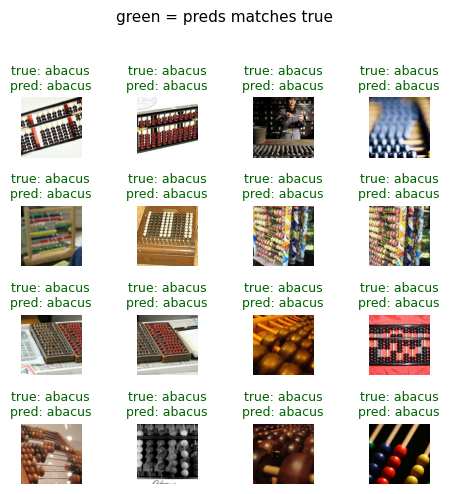

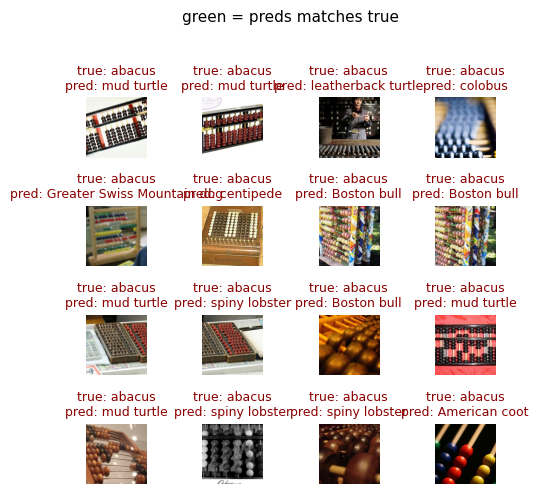

In [12]:
display_batch(vis, targets, pred)
display_batch(vis, targets, pred_512)


In [13]:

del convnext_pt
del convnext_pt_512
torch.cuda.empty_cache() if torch.cuda.is_available() else None

*A 2.3.0* : Because the model’s output logits correspond to the fixed 1,000 classes and their specific index ordering used during training. If we rely on directory-based labels, the class indices will not align with the model’s expected label space, leading to incorrect predictions and evaluation mismatches.

---
## 2.4 EfficientNetV2

**EfficientNetV2** (Tan & Le, 2021 — Google) builds upon EfficientNet by solving two limitations:
1. **Slow training speed** at high resolutions
2. **Depthwise convolutions are hardware-unfriendly** at early stages


<p>
<img src="content/efficient-net.png">
</p>

#### Key Innovations:

| Component | EfficientNet | EfficientNetV2 |
|---|---|---|
| Early stage block | MBConv | **Fused-MBConv** |
| NAS search space | Input resolution fixed | **Progressive learning** |
| Training regularization | Fixed augmentation | **Progressive augmentation** |
| Architecture search | FLOPs + Acc | FLOPs + Acc + **Training speed** |

**Fused-MBConv** replaces the depthwise conv + pointwise conv with a single **3×3 conv + pointwise conv**, which is faster on modern accelerators (TPUs, GPUs with tensor cores).


| vs V1 | What changed |
|--- | ---|
| Depthwise conv | Fused-MBConv in early stages  |
| Fixed image size  | Progressive learning (128→192→224)  |
| Fixed augmentation | Added training speed to NAS objective   |
| NAS target | Progressive augmentation  |
| SE block (Squeeze-and-Excitation) | Kept (only in MBConv stages)  |
| SiLU activation | Kept throughout   |
| NAS target | Progressive augmentation  |


Result:
  - ✅ 4× faster training than V1
  - ✅ 6.8× smaller model than V1 at same accuracy
  - ✅ SOTA ImageNet accuracy at the time (2021)
  - ✅ Better parameter efficiency

In [14]:
class MBConv(nn.Module):
    """Mobile Inverted Bottleneck (MBConv) — used in EfficientNet."""
    def __init__(self, in_channels: int, out_channels: int, expand_ratio: int = 4, stride: int = 1):
        super().__init__()
        hidden = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.block = nn.Sequential(
            # Pointwise expand
            nn.Conv2d(in_channels, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden), nn.SiLU(),
            # Depthwise 3×3
            nn.Conv2d(hidden, hidden, 3, stride=stride, padding=1, groups=hidden, bias=False),
            nn.BatchNorm2d(hidden), nn.SiLU(),
            # Pointwise project
            nn.Conv2d(hidden, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        out = self.block(x)
        return out + x if self.use_residual else out


class FusedMBConv(nn.Module):
    """
    Fused MBConv — key innovation in EfficientNetV2.
    Fuses the depthwise + pointwise-expand into a SINGLE 3×3 conv.
    This is more hardware-efficient at early stages.
    """
    def __init__(self, in_channels: int, out_channels: int, expand_ratio: int = 4, stride: int = 1):
        super().__init__()
        hidden = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.block = nn.Sequential(
            # Single fused 3×3 conv (replaces DWConv + pointwise-expand)
            nn.Conv2d(in_channels, hidden, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(hidden), nn.SiLU(),
            # Pointwise project
            nn.Conv2d(hidden, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        out = self.block(x)
        return out + x if self.use_residual else out


# ── Compare FLOPs: MBConv vs FusedMBConv ────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters())

C = 32  # channels
mb      = MBConv(C, C)
fused   = FusedMBConv(C, C)
x       = torch.randn(1, C, 56, 56)

print('📐 MBConv vs Fused-MBConv')
print(f'  MBConv      — params: {count_params(mb):>6,}  output: {mb(x).shape}')
print(f'  FusedMBConv — params: {count_params(fused):>6,}  output: {fused(x).shape}')
print('\n  FusedMBConv removes the depthwise step → fewer kernel launches,')
print('  better GPU utilization in early low-channel stages.')

📐 MBConv vs Fused-MBConv
  MBConv      — params:  9,920  output: torch.Size([1, 32, 56, 56])
  FusedMBConv — params: 41,280  output: torch.Size([1, 32, 56, 56])

  FusedMBConv removes the depthwise step → fewer kernel launches,
  better GPU utilization in early low-channel stages.


In [15]:
# ── EfficientNetV2-S via timm ────────────────────────────────────────────────
effv2 = timm.create_model('efficientnetv2_s', pretrained=False, num_classes=1000)

# Show which stages use FusedMBConv vs MBConv
print('=== EfficientNetV2-S — Block Distribution ===')
fused_count = mb_count = other_count = 0
for name, module in effv2.named_modules():
    cls = type(module).__name__
    if 'Fused' in cls: fused_count += 1
    elif 'InvertedResidual' in cls or 'MBConv' in cls: mb_count += 1

total_params = count_params(effv2)
print(f'  Total parameters : {total_params/1e6:.2f}M')
print(f'\n  EfficientNetV2-S uses:')
print(f'  • Fused-MBConv in early stages  (stages 0-2)  → faster training')
print(f'  • MBConv       in later stages  (stages 3-6)  → parameter efficient')

dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    out = effv2(dummy)
print(f'\n  Output: {out.shape}')

=== EfficientNetV2-S — Block Distribution ===
  Total parameters : 21.46M

  EfficientNetV2-S uses:
  • Fused-MBConv in early stages  (stages 0-2)  → faster training
  • MBConv       in later stages  (stages 3-6)  → parameter efficient

  Output: torch.Size([1, 1000])


---
## 2.5 ResNeXt & Wide Residual Networks

These are evolution of the classic ResNet that improve accuracy by rethinking **width** and **cardinality** (number of independent paths), rather than just adding more layers.

#### The Three Axes of Scaling (He et al.):
``` text
          Depth         Width         Cardinality
         (layers)     (channels)      (groups)
ResNet      ✅            ❌              ❌
WideResNet  ❌            ✅              ❌
ResNeXt     ❌            ❌              ✅
```

#### ResNeXt — Grouped Convolutions:
Instead of one wide transform, apply `C` independent parallel transforms (cardinality) and sum them. This is equivalent to group convolution and maps cleanly to the Inception idea.

`ResNeXt-50 (32×4d)` = cardinality 32, group width 4

In [16]:
class ResNetBottleneck(nn.Module):
    """Classic ResNet Bottleneck: 1×1 → 3×3 → 1×1."""
    expansion = 4

    def __init__(self, in_ch, mid_ch, stride=1):
        super().__init__()
        out_ch = mid_ch * self.expansion
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 1, bias=False), nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, bias=False), nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch),
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class ResNeXtBottleneck(nn.Module):
    """
    ResNeXt Bottleneck: same as ResNet but the 3×3 conv uses GROUPS.
    
    cardinality (C) = number of independent groups = "cardinality"
    base_width      = channels per group
    
    This achieves better accuracy at the same parameter count by
    leveraging more diverse feature transformations.
    """
    expansion = 2  # simplified for demo

    def __init__(self, in_ch, mid_ch, stride=1, cardinality=32, base_width=4):
        super().__init__()
        # Grouped channel width
        width   = int(mid_ch * (base_width / 64.0)) * cardinality
        out_ch  = mid_ch * self.expansion
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, width, 1, bias=False), nn.BatchNorm2d(width), nn.ReLU(inplace=True),
            # ← KEY: groups=cardinality (grouped convolution)
            nn.Conv2d(width, width, 3, stride=stride, padding=1,
                      groups=cardinality, bias=False),
            nn.BatchNorm2d(width), nn.ReLU(inplace=True),
            nn.Conv2d(width, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch),
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class WideResNetBlock(nn.Module):
    """
    Wide ResNet Block: fewer layers but WIDER channels (width_factor k).
    WRN-28-10 = 28 layers, width factor 10 → channels × 10.
    """
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.shortcut(x)


# ── Compare parameter efficiency ─────────────────────────────────────────────
in_ch = 256
resnet_block  = ResNetBottleneck(in_ch, 64)
resnext_block = ResNeXtBottleneck(in_ch, 128, cardinality=32, base_width=4)
wide_block    = WideResNetBlock(in_ch, 512)

x = torch.randn(2, 256, 28, 28)
print('📊 Architecture Comparison — Single Block')
print(f'  {"Block":<20} {"Params":>10}  {"Output shape"}')
print('  ' + '-'*50)
for name, block in [('ResNet-Bottleneck', resnet_block),
                     ('ResNeXt-Bottleneck', resnext_block),
                     ('WideResNet-Block',   wide_block)]:
    out = block(x)
    p   = count_params(block)
    print(f'  {name:<20} {p:>10,}  {out.shape}')

📊 Architecture Comparison — Single Block
  Block                    Params  Output shape
  --------------------------------------------------
  ResNet-Bottleneck        70,400  torch.Size([2, 256, 28, 28])
  ResNeXt-Bottleneck      151,040  torch.Size([2, 256, 28, 28])
  WideResNet-Block      3,671,552  torch.Size([2, 512, 28, 28])


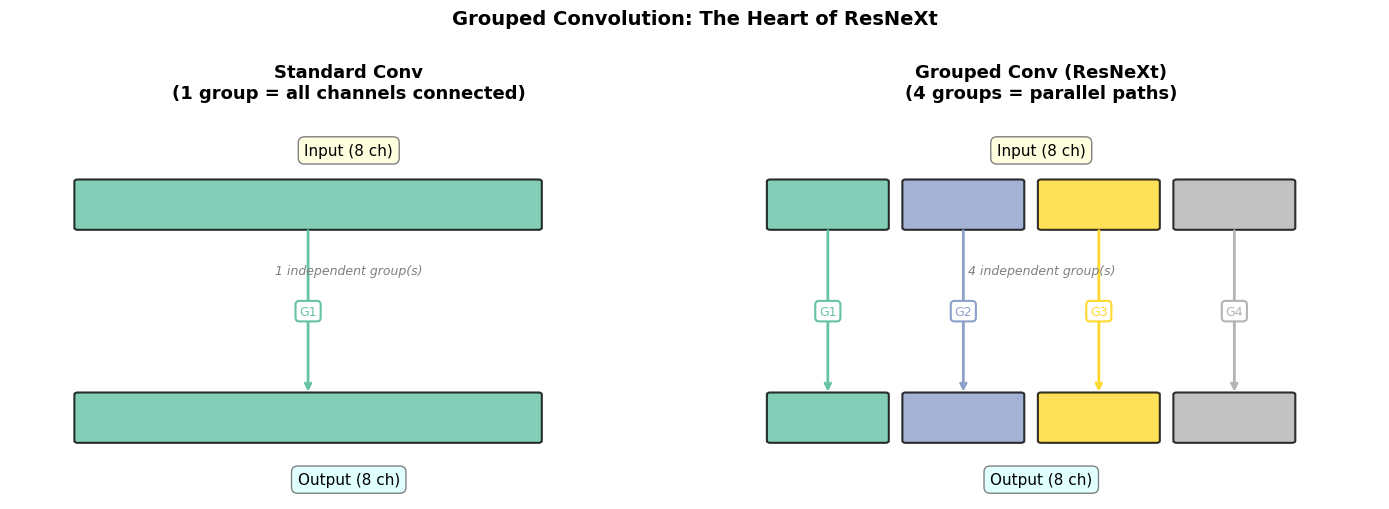

✅ Grouped convolutions split channels into independent groups,
   increasing model capacity (cardinality) without adding parameters.


In [17]:
# ── Visualize Grouped Convolution (the heart of ResNeXt) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def draw_conv_diagram(ax, title, n_groups, in_ch=8, out_ch=8, color='steelblue'):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ch_per_group = in_ch // n_groups
    colors = plt.cm.Set2(np.linspace(0, 1, n_groups))
    w = 8.0 / n_groups
    for g in range(n_groups):
        c = colors[g]
        x0 = 1 + g * w
        # Input block
        ax.add_patch(mpatches.FancyBboxPatch((x0, 7), w*0.85, 1.2, boxstyle='round,pad=0.05', fc=c, ec='k', lw=1.5, alpha=0.8))
        # Output block
        ax.add_patch(mpatches.FancyBboxPatch((x0, 1.5), w*0.85, 1.2, boxstyle='round,pad=0.05', fc=c, ec='k', lw=1.5, alpha=0.8))
        # Arrow
        cx = x0 + w*0.425
        ax.annotate('', xy=(cx, 2.7), xytext=(cx, 7.0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2))
        ax.text(cx, 4.85, f'G{g+1}', ha='center', va='center', fontsize=9, color=c,
                bbox=dict(fc='white', ec=c, boxstyle='round', lw=1.5, pad=0.3))
    ax.text(5, 9.0, f'Input ({in_ch} ch)', ha='center', va='center', fontsize=11,
            bbox=dict(fc='lightyellow', ec='gray', boxstyle='round', pad=0.4))
    ax.text(5, 0.5, f'Output ({out_ch} ch)', ha='center', va='center', fontsize=11,
            bbox=dict(fc='lightcyan', ec='gray', boxstyle='round', pad=0.4))
    ax.text(5, 5.8, f'{n_groups} independent group(s)', ha='center', fontsize=9, style='italic', color='gray')

draw_conv_diagram(axes[0], 'Standard Conv\n(1 group = all channels connected)', n_groups=1)
draw_conv_diagram(axes[1], 'Grouped Conv (ResNeXt)\n(4 groups = parallel paths)', n_groups=4)

plt.suptitle('Grouped Convolution: The Heart of ResNeXt', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grouped_conv.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grouped convolutions split channels into independent groups,')
print('   increasing model capacity (cardinality) without adding parameters.')

<a id='detection'></a>
## 🎯 3. SOTA Object Detection & Segmentation

###  3.1 - FasterRCNN
*It's a two-stage detector, not a backbone.* 

<p>
<img src="content/fastercnn.png" width="300" height="300">
</p>





It has multiple components but You can use a pretrained convolution neural network (CNN) as the basis for an R-CNN detector, also referred to as transfer learning. See Pretrained Deep Neural Networks (Deep Learning Toolbox). Use one of the following networks with the trainRCNNObjectDetector, trainFasterRCNNObjectDetector, or trainFastRCNNObjectDetector functions. To use any of these networks you must install the corresponding Deep Learning Toolbox™ model:

- 'alexnet (Deep Learning Toolbox)'
- 'vgg16 (Deep Learning Toolbox)'
- 'vgg19 (Deep Learning Toolbox)'
- 'resnet50 (Deep Learning Toolbox)'
- 'resnet101 (Deep Learning Toolbox)'
- 'inceptionv3 (Deep Learning Toolbox)'
- 'googlenet (Deep Learning Toolbox)'
- 'inceptionresnetv2 (Deep Learning Toolbox)'
- 'squeezenet (Deep Learning Toolbox)'

<p>
The Faster R-CNN detector adds a region proposal network (RPN) to generate region proposals directly in the network instead of using an external algorithm like Edge Boxes. The RPN uses <b>Anchor Boxes</b> for Object Detection. Generating region proposals in the network is faster and better tuned to your data.

Use the trainFasterRCNNObjectDetector function to train a Faster R-CNN object detector. The function returns a fasterRCNNObjectDetector that detects objects from an image.
</p>



<p>
<img src="content/fastrcnn.png">
</p>

### 3.1.1 Region Proposal Network (RPN)

The RPN slides over the feature map produced by the backbone (e.g., ResNet + FPN) and, at each spatial location, asks:

"Is there an object here, and if so, where exactly?"

---

### *Anchors Boxes*

At each feature map cell, the RPN places k anchor boxes of different scales and aspect ratios (e.g., 3 scales × 3 ratios = 9 anchors per location).

### Two heads on top of the RPN
For each anchor, the RPN predicts:

|      Head     | Output                       | What it does |
| --- | --- | --- |
|Classification |2 scores (object / background)| Is there any object here? |
|Regression      |4 deltas (Δx, Δy, Δw, Δh)     | Refine the anchor box to tightly fit the object |


---

### *Training signal*

- Anchors with IoU > 0.7 with a GT box → positive (object)
- Anchors with IoU < 0.3 → negative (background)
- RPN loss = L_cls (binary CE) + λ · L_reg (Smooth L1)

---

### *NMS ( Non-Maximum Suppression ) to filter proposals*
After scoring all anchors, Non-Maximum Suppression keeps the top-N proposals (e.g., 2000 during training, 300 at inference) before passing them downstream.
~20k raw anchors → RPN scoring → NMS → ~300 region proposals

### 3.1.2 RoI ( Region of Interest ) Pooling
*The problem*: region proposals have different sizes, but the classification head (FC layers) needs a fixed-size input.
RoI Pooling solves this by extracting a fixed H×W feature patch from the shared feature map for each proposal, regardless of its original size.
How it works
Given a proposal of size h × w on the feature map and a target output of H × W (e.g., 7×7):

- Divide the proposal region into an H × W grid of sub-windows
- Max-pool within each sub-window → one value per cell
- Output: always a 7 × 7 × C tensor ✅

```text
Feature Map
┌─────────────────────────────┐
│                             │
│   ┌──────────────┐          │
│   │   Proposal   │          │  ← irregular size (h × w)
│   │   region     │          │
│   └──────────────┘          │
└─────────────────────────────┘
          │
          ▼  Divide into 7×7 grid, max-pool each cell
     ┌─┬─┬─┬─┬─┬─┬─┐
     ├─┼─┼─┼─┼─┼─┼─┤
     ├─┼─┼─┼─┼─┼─┼─┤  → Fixed 7×7×C tensor
     ├─┼─┼─┼─┼─┼─┼─┤
     └─┴─┴─┴─┴─┴─┴─┘
```

### 3.1.1 - FasterRCNN + COCO-style detection


Run **COCO-pretrained Faster R-CNN (ResNet-50-FPN)** on a sample image to **draw boxes and labels** (80 COCO thing classes + background).


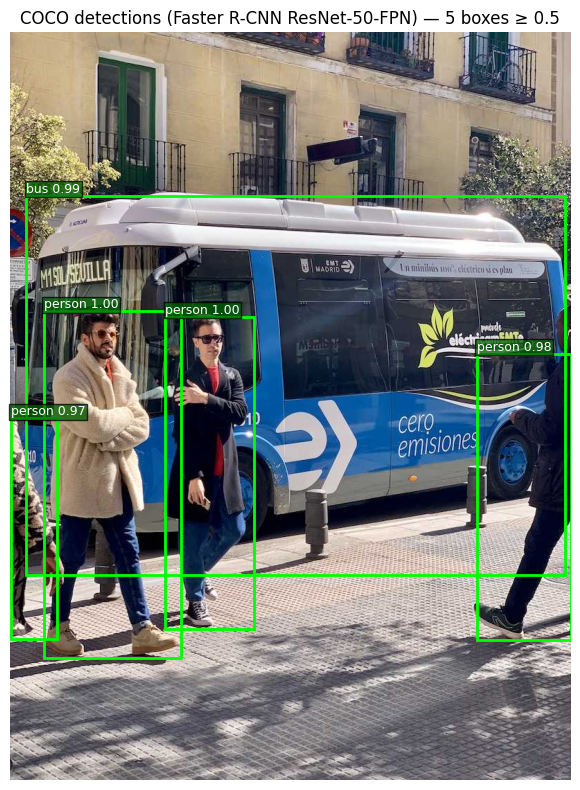

Done: 5 detections (COCO categories).


In [29]:
import io
import urllib.request

from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
coco_detector = fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()
coco_names = weights.meta['categories']
preprocess = weights.transforms()

IMAGE_URL = 'https://ultralytics.com/images/bus.jpg'
raw = urllib.request.urlopen(IMAGE_URL, timeout=30).read()
pil = Image.open(io.BytesIO(raw)).convert('RGB')
img_tensor = preprocess(pil).to(device)
with torch.no_grad():
    det_out = coco_detector([img_tensor])[0]

SCORE_THR = 0.5
keep = det_out['scores'] >= SCORE_THR
boxes = det_out['boxes'][keep].cpu()
scores = det_out['scores'][keep].cpu()
labels = det_out['labels'][keep].cpu()

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(pil)
for box, sc, lab in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box.tolist()
    rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='lime', linewidth=2)
    ax.add_patch(rect)
    name = coco_names[lab.item()]
    ax.text(x1, max(0, y1 - 4), f'{name} {sc:.2f}', color='white', fontsize=9,
            bbox=dict(facecolor='darkgreen', alpha=0.75, pad=1))
ax.set_title(f'COCO detections (Faster R-CNN ResNet-50-FPN) — {len(boxes)} boxes ≥ {SCORE_THR}', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Done: {len(boxes)} detections (COCO categories).')



Object detection localizes objects in images (bounding boxes + class labels). Modern detectors build upon powerful CNN backbones paired with **Feature Pyramid Networks (FPN)** for multi-scale detection.

```bash
Input Image
     │
  Backbone (CNN)                    ← Feature extraction
  C2, C3, C4, C5 (multi-scale)      ← Different resolutions
     │
  Neck (FPN / BiFPN / PANet)        ← Feature fusion
  P2, P3, P4, P5, P6               ← Enriched feature pyramid
     │
  Head (Detection / Segmentation)   ← Predictions
  Boxes, Scores, Masks
```

### 3.2 YOLO Series (v8–v10)

**YOLO (You Only Look Once)** is a single-stage detector — it predicts boxes and classes in a single forward pass, making it extremely fast.

| Version | Key Innovation |
|---|---|
| YOLOv5 | CSP bottleneck, PyTorch native |
| YOLOv8 | Decoupled head, anchor-free, task-unified |
| YOLOv9 | GELAN, Programmable Gradient Information (PGI) |
| YOLOv10 | Consistent dual assignments, NMS-free inference |

### Why YOLO “Only Looks Once”

**YOLO (You Only Look Once)** is named after its core idea: it performs **object detection in a single forward pass of the network**, instead of using multiple stages or repeated region proposals.

---

### Traditional Object Detection (Before YOLO)

Earlier methods like:

* R-CNN
* Fast R-CNN
* Faster R-CNN

work in **multiple steps**:

1. Generate candidate regions (region proposals)
2. Run a CNN on each region
3. Classify and refine bounding boxes

This means the model effectively “looks” at the image **many times**, making it slower and more complex.

---

### YOLO Approach (Single Pass)

YOLO reframes object detection as a **single regression problem**:

* Input: entire image
* Output: bounding boxes + class probabilities

The image is divided into a grid, and for each cell the model predicts:

* Bounding box coordinates
* Object confidence
* Class probabilities

This happens **all at once**, in one pass through the network.

---

### Why “Only Once” Matters

- 1. Speed

* No region proposal stage
* Real-time detection (e.g., video, autonomous systems)

- 2. Global Context

* The model sees the **entire image simultaneously**
* Reduces false positives compared to patch-based methods

- 3. Simplicity

* End-to-end training
* Single unified architecture


---

### Summary

Instead of asking:

> “What objects exist in these many regions?”

YOLO asks:

> “What objects exist in this image, and where are they?”

And answers it **in one shot**.

YOLO “only looks once” because it:

* Processes the entire image **in a single forward pass**
* Predicts **all objects simultaneously**
* Eliminates the need for multi-stage pipelines

This design is what makes YOLO fast, efficient, and widely used in real-time computer vision systems.


#### YOLOv8 Architecture:
- **Backbone**: CSPDarknet with C2f blocks
- **Neck**: FPN + PAN (bi-directional feature fusion)
- **Head**: Anchor-free, decoupled (separate cls + reg branches)

In [30]:
class C2fBlock(nn.Module):
    """
    C2f (Cross-Stage Partial with 2 convolutions + feature flow) — YOLOv8.
    Inspired by CSP but with direct gradient flow paths.

    Splits channels, processes one part through N bottlenecks,
    then concatenates ALL intermediate outputs for rich feature reuse.
    """
    def __init__(self, in_ch: int, out_ch: int, n_bottlenecks: int = 1, shortcut: bool = True):
        super().__init__()
        hidden = out_ch // 2
        # Initial split conv
        self.cv1 = nn.Sequential(
            nn.Conv2d(in_ch, 2 * hidden, 1, bias=False),
            nn.BatchNorm2d(2 * hidden), nn.SiLU()
        )
        # Final aggregation conv
        self.cv2 = nn.Sequential(
            nn.Conv2d((2 + n_bottlenecks) * hidden, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.SiLU()
        )
        # Bottlenecks applied to the 2nd half
        self.bottlenecks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(hidden, hidden, 3, padding=1, bias=False),
                nn.BatchNorm2d(hidden), nn.SiLU(),
                nn.Conv2d(hidden, hidden, 3, padding=1, bias=False),
                nn.BatchNorm2d(hidden), nn.SiLU(),
            ) for _ in range(n_bottlenecks)
        ])
        self.shortcut = shortcut and in_ch == out_ch

    def forward(self, x):
        # Split along channel dim
        out = list(self.cv1(x).chunk(2, dim=1))  # [left, right]
        # Process right part through bottlenecks, collect all intermediate feats
        for bn in self.bottlenecks:
            out.append(bn(out[-1]))
        # Concatenate all parts and fuse
        return self.cv2(torch.cat(out, dim=1))


class YOLOv8DetectionHead(nn.Module):
    """
    Simplified YOLOv8 Decoupled Detection Head.
    
    KEY CHANGE from YOLOv5: Decouples classification and regression.
    • Regression branch: predicts box offsets (4 values)
    • Classification branch: predicts class probabilities
    → Better gradient flow per task (no coupling)
    """
    def __init__(self, in_ch: int, num_classes: int = 80, reg_max: int = 16):
        super().__init__()
        hidden = max(in_ch, 64)
        # Regression branch (4 box coords × reg_max)
        self.reg_branch = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1), nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1), nn.SiLU(),
            nn.Conv2d(hidden, 4 * reg_max, 1)
        )
        # Classification branch
        self.cls_branch = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1), nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1), nn.SiLU(),
            nn.Conv2d(hidden, num_classes, 1)
        )

    def forward(self, feat):
        box  = self.reg_branch(feat)   # (B, 4*reg_max, H, W)
        cls  = self.cls_branch(feat)   # (B, num_classes, H, W)
        return box, cls


# ── Test C2f and detection head ───────────────────────────────────────────────
x   = torch.randn(2, 256, 40, 40)   # P4 feature map
c2f = C2fBlock(256, 256, n_bottlenecks=3)
det = YOLOv8DetectionHead(256, num_classes=80)

feat     = c2f(x)
box, cls = det(feat)

print('🎯 YOLOv8 Building Blocks')
print(f'  Input feat    : {x.shape}')
print(f'  C2f output    : {feat.shape}')
print(f'  Box output    : {box.shape}  (4 × reg_max per cell)')
print(f'  Class output  : {cls.shape}  (80 COCO classes per cell)')
print(f'  C2f params    : {count_params(c2f):,}')
print(f'  Head params   : {count_params(det):,}')

🎯 YOLOv8 Building Blocks
  Input feat    : torch.Size([2, 256, 40, 40])
  C2f output    : torch.Size([2, 256, 40, 40])
  Box output    : torch.Size([2, 64, 40, 40])  (4 × reg_max per cell)
  Class output  : torch.Size([2, 80, 40, 40])  (80 COCO classes per cell)
  C2f params    : 1,116,672
  Head params   : 2,397,328


---
### 3.2 Mask R-CNN / Faster R-CNN

**Faster R-CNN** (Ren et al., 2015) introduced the **Region Proposal Network (RPN)** — a fully convolutional network that shares features with the detector and proposes candidate object regions.

**Mask R-CNN** (He et al., 2017) extends Faster R-CNN with a parallel **mask prediction branch** and **RoIAlign** (replacing RoIPool for pixel-accurate alignment).

```bash
Image → Backbone+FPN → RPN → RoIAlign → Box Head → Class + Box
                                       ↘ Mask Head → Binary Mask
```

#### RoIAlign — Why it matters:
RoIPool used integer rounding → misaligned features. RoIAlign uses **bilinear interpolation** to sample features at exact (non-integer) positions, critical for pixel-level segmentation.

In [31]:
# ── Faster R-CNN from torchvision with pretrained weights ─────────────────────
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights

# Load Faster R-CNN (pretrained on COCO)
faster_rcnn = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).eval()

print('=== Faster R-CNN (ResNet50 + FPN) ===')
print(f'  Backbone: {type(faster_rcnn.backbone).__name__}')
print(f'  RPN     : {type(faster_rcnn.rpn).__name__}')
print(f'  RoI Head: {type(faster_rcnn.roi_heads).__name__}')
print(f'  Total params: {count_params(faster_rcnn)/1e6:.1f}M')

# Inference demo with a random image
dummy_img = [torch.rand(3, 480, 640)]  # Faster R-CNN expects a list of images
with torch.no_grad():
    predictions = faster_rcnn(dummy_img)

print(f'\n  Inference on (3×480×640) image:')
print(f'  → Boxes detected : {predictions[0]["boxes"].shape[0]} ')
if predictions[0]["scores"].numel() > 0:
    print(f'  → Box scores     : min={predictions[0]["scores"].min():.3f},',
          f'max={predictions[0]["scores"].max(dim=0):.3f}')
else:
    print('  → Box scores     : N/A')
    
print(f'  → Labels         : {predictions[0]["labels"].unique().tolist()}')

=== Faster R-CNN (ResNet50 + FPN) ===
  Backbone: BackboneWithFPN
  RPN     : RegionProposalNetwork
  RoI Head: RoIHeads
  Total params: 41.8M

  Inference on (3×480×640) image:
  → Boxes detected : 0 
  → Box scores     : N/A
  → Labels         : []


In [32]:
# ── Mask R-CNN demo ───────────────────────────────────────────────────────────
mask_rcnn = maskrcnn_resnet50_fpn(
    weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT
).eval()

print('=== Mask R-CNN (ResNet50 + FPN) ===')
print(f'  Total params : {count_params(mask_rcnn)/1e6:.1f}M')

# The mask head is the extra branch
mask_head = mask_rcnn.roi_heads.mask_head
print(f'  Mask Head    : {type(mask_head).__name__}')

dummy_img = [torch.rand(3, 480, 640)]
with torch.no_grad():
    preds = mask_rcnn(dummy_img)

print(f'\n  Inference on (3×480×640) image:')
print(f'  → Boxes  : {preds[0]["boxes"].shape}')
print(f'  → Masks  : {preds[0]["masks"].shape}  ← per-instance binary masks!')
print(f'     Mask shape = (N_instances, 1, H, W) = pixel-level prediction')

# Visualize a detected mask schematically
if preds[0]['masks'].shape[0] > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(dummy_img[0].permute(1, 2, 0))
    axes[0].set_title('Input Image (random)', fontsize=11)
    mask = preds[0]['masks'][0, 0].numpy()
    axes[1].imshow(mask, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title(f'Instance Mask #1 (score={preds[0]["scores"][0]:.3f})', fontsize=11)
    for ax in axes: ax.axis('off')
    plt.suptitle('Mask R-CNN — Instance Segmentation Output', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('mask_rcnn_demo.png', dpi=120, bbox_inches='tight')
    plt.show()

=== Mask R-CNN (ResNet50 + FPN) ===
  Total params : 44.4M
  Mask Head    : MaskRCNNHeads

  Inference on (3×480×640) image:
  → Boxes  : torch.Size([0, 4])
  → Masks  : torch.Size([0, 1, 480, 640])  ← per-instance binary masks!
     Mask shape = (N_instances, 1, H, W) = pixel-level prediction


---
### 3.3 EfficientDet

**EfficientDet** (Tan et al., 2020 — Google) applies the **compound scaling** principle from EfficientNet to object detection. It introduces **BiFPN (Bidirectional FPN)** — a learnable, weighted feature pyramid that fuses information in both directions.

#### BiFPN vs Classic FPN:
```bash
FPN (top-down only):      P6 → P5 → P4 → P3
PANet (+ bottom-up):      P3 → P4 → P5 → P6
BiFPN (bidirectional):    Both, with learnable weights + skip connections
```

**Weighted fusion**: Instead of simple sum/concatenation, BiFPN learns per-feature weights:
$$P^{td}_{i} = \frac{w_1 P_i + w_2 \cdot resize(P_{i+1})}{w_1 + w_2 + \epsilon}$$

In [33]:
class BiFPNLayer(nn.Module):
    """
    BiFPN Layer — Bidirectional Feature Pyramid Network.
    
    Fuses features from P3 to P7 in both top-down and bottom-up directions
    with LEARNABLE weights (fast normalized fusion).
    """
    def __init__(self, num_channels: int = 64, num_levels: int = 5, eps: float = 1e-4):
        super().__init__()
        self.num_levels = num_levels
        self.eps = eps
        # Depthwise separable convolutions for feature refinement
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(num_channels, num_channels, 3, padding=1, groups=num_channels, bias=False),
                nn.Conv2d(num_channels, num_channels, 1, bias=False),
                nn.BatchNorm2d(num_channels),
                nn.SiLU()
            ) for _ in range(num_levels * 2 - 2)  # top-down + bottom-up paths
        ])
        # Learnable fusion weights (initialized to 1 = equal weight)
        self.td_weights = nn.Parameter(torch.ones(num_levels - 1, 2))  # top-down
        self.bu_weights = nn.Parameter(torch.ones(num_levels - 1, 3))  # bottom-up

    def weighted_sum(self, feats, weights):
        """Fast normalized weighted fusion."""
        w = F.relu(weights)  # ensure positive
        w = w / (w.sum() + self.eps)
        return sum(w[i] * feats[i] for i in range(len(feats)))

    def forward(self, features: list) -> list:
        # features: [P3, P4, P5, P6, P7]
        # ── TOP-DOWN PASS (high-level → low-level) ─────────────
        td_features = [features[-1]]  # Start from P7
        for i in range(self.num_levels - 2, -1, -1):
            upsampled = F.interpolate(td_features[-1], size=features[i].shape[2:], mode='nearest')
            fused = self.weighted_sum([features[i], upsampled], self.td_weights[self.num_levels - 2 - i])
            td_features.append(self.convs[self.num_levels - 2 - i](fused))
        td_features = td_features[::-1]  # reverse to [P3_td, P4_td, ..., P7_td]
        # ── BOTTOM-UP PASS (low-level → high-level) ─────────────
        out_features = [td_features[0]]  # Start from P3_td
        for i in range(1, self.num_levels):
            downsampled = F.max_pool2d(out_features[-1], kernel_size=2)
            if i < self.num_levels - 1:
                fused = self.weighted_sum(
                    [features[i], td_features[i], downsampled],
                    self.bu_weights[i - 1]
                )
            else:
                fused = self.weighted_sum([features[i], downsampled], self.bu_weights[i-1][:2])
            out_features.append(self.convs[self.num_levels - 1 + i - 1](fused))
        return out_features


# ── Test BiFPN with dummy FPN features ───────────────────────────────────────
C = 64   # BiFPN channels
# Simulate FPN outputs [P3, P4, P5, P6, P7] at decreasing resolutions
feats = [
    torch.randn(2, C, 64, 64),  # P3
    torch.randn(2, C, 32, 32),  # P4
    torch.randn(2, C, 16, 16),  # P5
    torch.randn(2, C, 8,  8 ),  # P6
    torch.randn(2, C, 4,  4 ),  # P7
]

bifpn = BiFPNLayer(num_channels=C, num_levels=5)
out   = bifpn(feats)

print('🔀 BiFPN — Bidirectional Feature Pyramid')
print(f'  BiFPN params: {count_params(bifpn):,}')
print('\n  Input (FPN features)  →  Output (BiFPN features):')
levels = ['P3', 'P4', 'P5', 'P6', 'P7']
for i, (inp, oup, lvl) in enumerate(zip(feats, out, levels)):
    print(f'    {lvl}: {tuple(inp.shape[2:])} → {tuple(oup.shape[2:])}  (same spatial, richer semantics)')

🔀 BiFPN — Bidirectional Feature Pyramid
  BiFPN params: 38,420

  Input (FPN features)  →  Output (BiFPN features):
    P3: (64, 64) → (64, 64)  (same spatial, richer semantics)
    P4: (32, 32) → (32, 32)  (same spatial, richer semantics)
    P5: (16, 16) → (16, 16)  (same spatial, richer semantics)
    P6: (8, 8) → (8, 8)  (same spatial, richer semantics)
    P7: (4, 4) → (4, 4)  (same spatial, richer semantics)


---
<a id='trends'></a>
## 🔬 4. Key Trends and Characteristics

### 4.1 Attention Mechanisms in CNNs

Modern CNNs incorporate **channel attention** and **spatial attention** to focus on the most relevant features and locations:

#### Squeeze-and-Excitation (SE) — Channel Attention
- **Squeeze**: Global average pool → compress spatial info into a vector
- **Excite**: Two FC layers learn channel-wise importance weights
- **Scale**: Multiply feature maps by these weights

#### CBAM — Convolutional Block Attention Module
Applies **channel attention THEN spatial attention** sequentially.

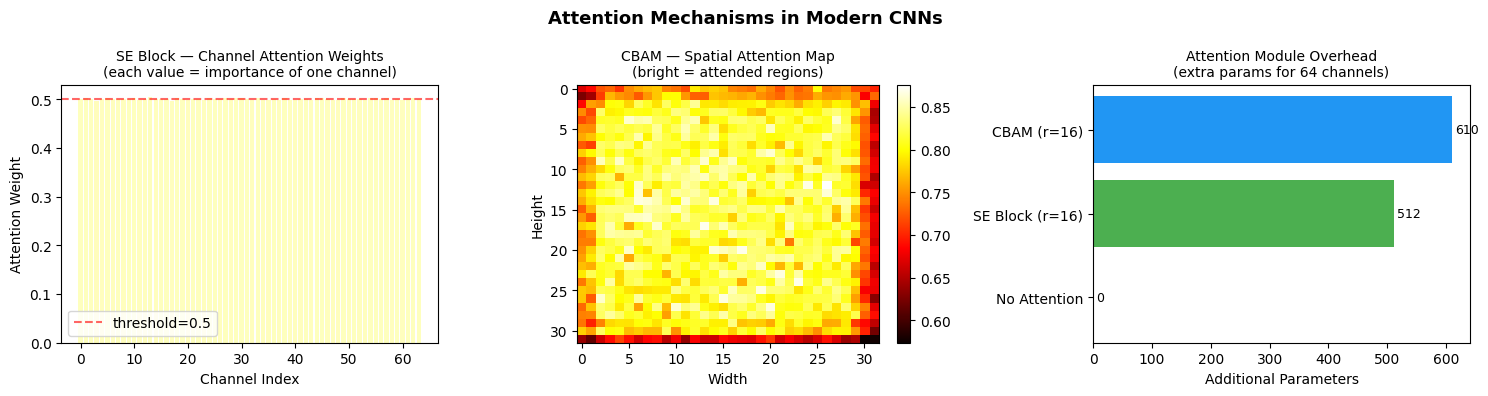

SE Block params   : 512
CBAM params       : 610
→ Very small overhead for significant accuracy gains!


In [23]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block (Hu et al., 2018).
    Recalibrates channel-wise feature responses adaptively.
    
    ratio: reduction ratio (higher = fewer params in excitation)
    """
    def __init__(self, channels: int, ratio: int = 16):
        super().__init__()
        self.squeeze  = nn.AdaptiveAvgPool2d(1)   # Global average pooling
        self.excite   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // ratio, bias=False),  # compress
            nn.ReLU(inplace=True),
            nn.Linear(channels // ratio, channels, bias=False),  # expand
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        # Squeeze: (B,C,H,W) → (B,C,1,1) → (B,C)
        s = self.squeeze(x)
        # Excite: (B,C) → (B,C) channel weights in [0,1]
        e = self.excite(s).view(B, C, 1, 1)
        # Scale: channel-wise recalibration
        return x * e


class CBAM(nn.Module):
    """
    CBAM — Convolutional Block Attention Module (Woo et al., 2018).
    Applies sequential channel + spatial attention.
    """
    def __init__(self, channels: int, ratio: int = 16, kernel_size: int = 7):
        super().__init__()
        # --- Channel Attention ---
        self.avg_pool  = nn.AdaptiveAvgPool2d(1)
        self.max_pool  = nn.AdaptiveMaxPool2d(1)
        self.chan_mlp  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // ratio, bias=False), nn.ReLU(),
            nn.Linear(channels // ratio, channels, bias=False)
        )
        # --- Spatial Attention ---
        padding = (kernel_size - 1) // 2
        self.spat_conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)

    def channel_attention(self, x):
        B, C, _, _ = x.shape
        avg = self.chan_mlp(self.avg_pool(x))
        mx  = self.chan_mlp(self.max_pool(x))
        return torch.sigmoid(avg + mx).view(B, C, 1, 1)

    def spatial_attention(self, x):
        # Compute avg and max along channel dim → 2-channel map
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True).values
        combined = torch.cat([avg, mx], dim=1)  # (B, 2, H, W)
        return torch.sigmoid(self.spat_conv(combined))

    def forward(self, x):
        x = x * self.channel_attention(x)   # Channel attention
        x = x * self.spatial_attention(x)   # Spatial attention
        return x


# ── Visualize attention maps ──────────────────────────────────────────────────
torch.manual_seed(0)
x   = torch.randn(1, 64, 32, 32)
se  = SEBlock(64, ratio=16)
cbam = CBAM(64)

with torch.no_grad():
    # SE channel weights
    se_weights = se.excite(se.squeeze(x).flatten(1)).squeeze().numpy()
    # CBAM spatial map
    x_chan = x * cbam.channel_attention(x)
    spat_map = cbam.spatial_attention(x_chan).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SE channel weights
axes[0].bar(range(len(se_weights)), se_weights, color=plt.cm.RdYlGn(se_weights))
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='threshold=0.5')
axes[0].set_title('SE Block — Channel Attention Weights\n(each value = importance of one channel)', fontsize=10)
axes[0].set_xlabel('Channel Index'); axes[0].set_ylabel('Attention Weight')
axes[0].legend()

# CBAM spatial map
im = axes[1].imshow(spat_map, cmap='hot', aspect='auto')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('CBAM — Spatial Attention Map\n(bright = attended regions)', fontsize=10)
axes[1].set_xlabel('Width'); axes[1].set_ylabel('Height')

# Parameter comparison
models_info = [
    ('No Attention', 0),
    ('SE Block (r=16)', count_params(se)),
    ('CBAM (r=16)', count_params(cbam)),
]
names, params = zip(*models_info)
bars = axes[2].barh(names, params, color=['#aaaaaa', '#4CAF50', '#2196F3'])
axes[2].set_title('Attention Module Overhead\n(extra params for 64 channels)', fontsize=10)
axes[2].set_xlabel('Additional Parameters')
for bar, p in zip(bars, params):
    axes[2].text(p + 5, bar.get_y() + bar.get_height()/2, f'{p:,}', va='center', fontsize=9)

plt.suptitle('Attention Mechanisms in Modern CNNs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_mechanisms.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'SE Block params   : {count_params(se):,}')
print(f'CBAM params       : {count_params(cbam):,}')
print('→ Very small overhead for significant accuracy gains!')

---
### 4.2 Efficiency vs Performance: FLOPs Analysis

A central challenge in modern CV: **maximize accuracy per compute budget (FLOPs)**.

The **FLOPs** (Floating Point Operations) of a conv layer are:
$$\text{FLOPs} = 2 \times C_{in} \times C_{out} \times k^2 \times H \times W$$

Key efficiency techniques:
- **Depthwise Separable Conv**: reduces FLOPs by ~8-9×
- **Grouped Convolutions**: reduces FLOPs by `1/groups`
- **Pruning**: removes low-magnitude weights
- **Knowledge Distillation**: small student learns from large teacher

📊 FLOPs Comparison  (Cin=128, Cout=256, 3×3, H=W=56)
  Method                        GFLOPs  vs. Standard
  --------------------------------------------------
  Standard Conv 3×3               1.85  baseline
  Grouped Conv (g=4)              0.46  25.00%
  Grouped Conv (g=8)              0.23  12.50%
  Depthwise Sep.                  0.21  11.50%


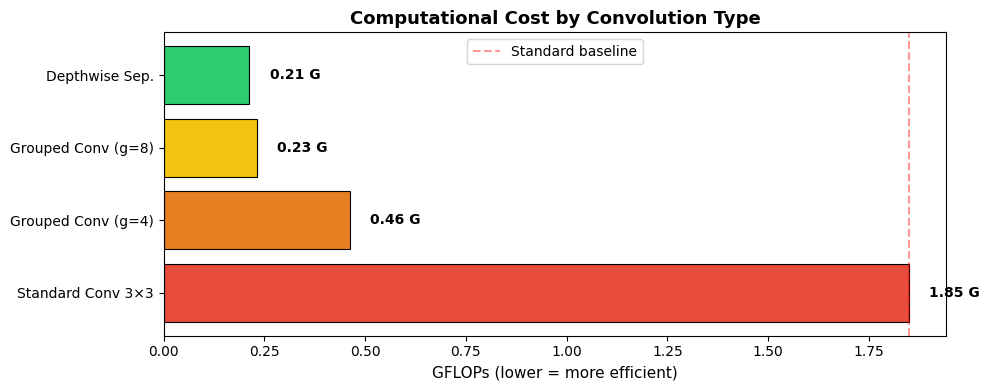

In [ ]:
def conv_flops(Cin, Cout, k, H, W, groups=1):
    """FLOPs for a convolution layer (multiply-accumulate × 2)."""
    return 2 * Cin * Cout * (k ** 2) * H * W / groups

def depthwise_sep_flops(Cin, Cout, k, H, W):
    """Depthwise separable = DWConv + PWConv."""
    dw = conv_flops(Cin, Cin, k, H, W, groups=Cin)   # DWConv (groups=Cin)
    pw = conv_flops(Cin, Cout, 1, H, W)               # 1×1 PWConv
    return dw + pw

# ── FLOPs comparison for a typical layer ─────────────────────────────────────
Cin, Cout, k, H, W = 128, 256, 3, 56, 56

std_flops  = conv_flops(Cin, Cout, k, H, W)
dws_flops  = depthwise_sep_flops(Cin, Cout, k, H, W)
g4_flops   = conv_flops(Cin, Cout, k, H, W, groups=4)
g8_flops   = conv_flops(Cin, Cout, k, H, W, groups=8)

results = [
    ('Standard Conv 3×3', std_flops, 'baseline'),
    ('Grouped Conv (g=4)', g4_flops, f'{g4_flops/std_flops:.2%}'),
    ('Grouped Conv (g=8)', g8_flops, f'{g8_flops/std_flops:.2%}'),
    ('Depthwise Sep.', dws_flops, f'{dws_flops/std_flops:.2%}'),
]

print(f'📊 FLOPs Comparison  (Cin={Cin}, Cout={Cout}, 3×3, H=W={H})')
print(f'  {"Method":<25} {"GFLOPs":>10}  {"vs. Standard"}')
print('  ' + '-'*50)
for name, flops, ratio in results:
    print(f'  {name:<25} {flops/1e9:>10.2f}  {ratio}')

# Visualization
fig, ax = plt.subplots(figsize=(10, 4))
names_plot = [r[0] for r in results]
gflops     = [r[1]/1e9 for r in results]
colors     = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = ax.barh(names_plot, gflops, color=colors, edgecolor='k', linewidth=0.8)
for bar, g in zip(bars, gflops):
    ax.text(g + 0.05, bar.get_y() + bar.get_height()/2,
            f'{g:.2f} G', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('GFLOPs (lower = more efficient)', fontsize=11)
ax.set_title('Computational Cost by Convolution Type', fontsize=13, fontweight='bold')
ax.axvline(std_flops/1e9, color='red', linestyle='--', alpha=0.4, label='Standard baseline')
ax.legend()
plt.tight_layout()
#plt.savefig('figures/flops_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
### 4.3 1D-CNNs for Temporal Signal Analysis

**1D-CNNs** apply convolutions along the **time dimension** instead of spatial dimensions. They are particularly effective for:
- 📈 Time-series classification (ECG, EEG, accelerometer)
- 🎵 Audio signal processing
- 🧬 Genomic sequence analysis

The same architectural improvements (residual connections, attention, depthwise conv) apply to 1D.

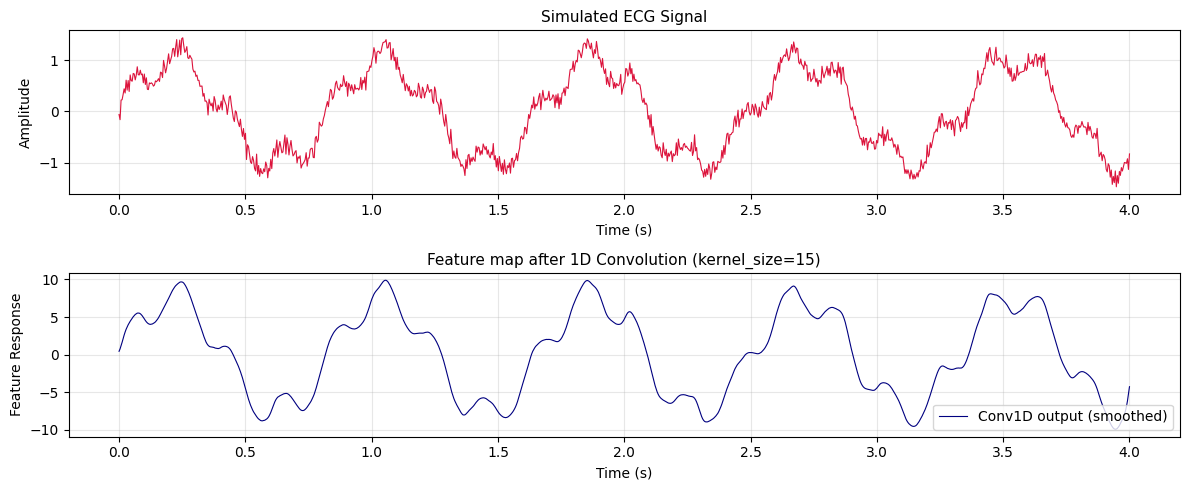

🫀 1D CNN for ECG Classification
  Input  : (batch=1, channels=1, timesteps=1000)
  Output : torch.Size([1, 5])  (5 heart rhythm classes)
  Params : 959.2K


In [ ]:
class Residual1DBlock(nn.Module):
    """
    1D Residual Block for temporal signal classification.
    Architecture identical to ResNet but with nn.Conv1d.
    
    Input:  (Batch, Channels, Time)
    Output: (Batch, Channels, Time)
    """
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int = 7, stride: int = 1):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm1d(out_ch)
        )
        self.shortcut = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if in_ch != out_ch or stride != 1 else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class TCNClassifier(nn.Module):
    """
    Temporal CNN Classifier — designed for ECG / time-series tasks.
    Uses dilated convolutions to capture long-range temporal dependencies.
    """
    def __init__(self, in_channels: int = 1, num_classes: int = 5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True)
        )
        self.stages = nn.Sequential(
            Residual1DBlock(32, 64,  stride=2),
            Residual1DBlock(64, 128, stride=2),
            Residual1DBlock(128, 256, stride=2),
        )
        # Channel attention (1D SE block)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(256, 16), nn.ReLU(),
            nn.Linear(16, 256), nn.Sigmoid()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        # Apply 1D channel attention
        w = self.se(x).unsqueeze(-1)
        x = x * w
        return self.classifier(x)


# ── ECG signal simulation ─────────────────────────────────────────────────────
t     = np.linspace(0, 4, 1000)  # 4 seconds at 250Hz
ecg   = (np.sin(2 * np.pi * 1.2 * t) + 0.3 * np.sin(2 * np.pi * 5 * t)
         + 0.1 * np.random.randn(len(t)))

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(t, ecg, color='crimson', linewidth=0.8)
axes[0].set_title('Simulated ECG Signal', fontsize=11)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Show how 1D conv kernel slides over time
kernel_size = 15
demo_filter = np.hamming(kernel_size)
feature = np.convolve(ecg, demo_filter, mode='same')
axes[1].plot(t, feature, color='navy', linewidth=0.8, label='Conv1D output (smoothed)')
axes[1].set_title('Feature map after 1D Convolution (kernel_size=15)', fontsize=11)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Feature Response')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('ecg_1dcnn.png', dpi=120, bbox_inches='tight')
plt.show()

# Test the 1D CNN
model_1d = TCNClassifier(in_channels=1, num_classes=5)
ecg_batch = torch.tensor(ecg, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,1000)
with torch.no_grad():
    logits = model_1d(ecg_batch)

print('🫀 1D CNN for ECG Classification')
print(f'  Input  : (batch=1, channels=1, timesteps=1000)')
print(f'  Output : {logits.shape}  (5 heart rhythm classes)')
print(f'  Params : {count_params(model_1d)/1e3:.1f}K')

---
### 4.4 Transfer Learning: Fine-Tuning a Pretrained CNN

**Transfer Learning** is the single most impactful practice in modern CV. Instead of training from scratch:

1. Start from a model pretrained on **ImageNet** (1.2M images, 1000 classes)
2. **Replace** the classification head for your task
3. **Fine-tune** all or part of the network

#### Fine-tuning strategies:
| Strategy | Frozen layers | When to use |
|---|---|---|
| **Feature extraction** | All backbone | Very small dataset (<1K images) |
| **Partial fine-tuning** | Early stages | Small-medium dataset |
| **Full fine-tuning** | None | Large dataset, similar domain |
| **Progressive unfreezing** | Layer by layer | Best results, prevents catastrophic forgetting |

In [26]:
class TransferLearningModel(nn.Module):
    """
    Demonstrates three fine-tuning strategies:
    1. Feature extraction   — backbone frozen, only head trained
    2. Partial fine-tuning  — last stage + head trained
    3. Full fine-tuning     — entire network trained (lower LR)
    """
    def __init__(self, backbone_name: str, num_classes: int, strategy: str = 'partial'):
        super().__init__()
        # Load pretrained backbone
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=False,      # Set True in practice!
            num_classes=0,         # Remove original head
            global_pool='avg'      # Global average pool
        )
        feat_dim = self.backbone.num_features
        # Custom head for new task
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(p=0.2),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Linear(256, num_classes)
        )
        # Apply strategy
        self._apply_strategy(strategy)

    def _apply_strategy(self, strategy: str):
        if strategy == 'feature_extraction':
            # Freeze entire backbone
            for p in self.backbone.parameters():
                p.requires_grad = False

        elif strategy == 'partial':
            # Freeze all backbone, then unfreeze last stage
            for p in self.backbone.parameters():
                p.requires_grad = False
            # Unfreeze last ConvNeXt stage
            for p in list(self.backbone.parameters())[-30:]:
                p.requires_grad = True

        elif strategy == 'full':
            # All parameters trainable (use lower LR for backbone)
            for p in self.backbone.parameters():
                p.requires_grad = True

    def get_optimizer_groups(self, head_lr: float = 1e-3, backbone_lr: float = 1e-5):
        """Differential learning rates: head gets higher LR than backbone."""
        return [
            {'params': self.backbone.parameters(), 'lr': backbone_lr},
            {'params': self.head.parameters(),     'lr': head_lr},
        ]

    def forward(self, x):
        features = self.backbone(x)  # (B, feat_dim)
        return self.head(features)


# ── Compare strategies ───────────────────────────────────────────────────────
print('📦 Transfer Learning Strategies — ConvNeXt-Tiny → CIFAR-10 (10 classes)')
print(f'  {"Strategy":<25} {"Trainable":>12}  {"Frozen":>10}')
print('  ' + '-'*55)

for strategy in ['feature_extraction', 'partial', 'full']:
    model_tl = TransferLearningModel('convnext_tiny', num_classes=10, strategy=strategy)
    trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
    frozen    = sum(p.numel() for p in model_tl.parameters() if not p.requires_grad)
    print(f'  {strategy:<25} {trainable/1e6:>10.2f}M  {frozen/1e6:>8.2f}M')

print('\n  Recommendation:')
print('  • Small dataset   → feature_extraction (avoid overfitting)')
print('  • Medium dataset  → partial (good balance)')
print('  • Large dataset   → full (with differential LR)')

📦 Transfer Learning Strategies — ConvNeXt-Tiny → CIFAR-10 (10 classes)
  Strategy                     Trainable      Frozen
  -------------------------------------------------------
  feature_extraction              0.20M     27.82M
  partial                        14.49M     13.53M
  full                           28.02M      0.00M

  Recommendation:
  • Small dataset   → feature_extraction (avoid overfitting)
  • Medium dataset  → partial (good balance)
  • Large dataset   → full (with differential LR)


In [27]:
# ── Progressive unfreezing scheduler ─────────────────────────────────────────
def progressive_unfreeze(
    model: TransferLearningModel,
    epoch: int,
    unfreeze_schedule: dict
):
    """
    Progressively unfreezes backbone layers epoch by epoch.
    This avoids catastrophic forgetting of pretrained features.
    
    unfreeze_schedule: {epoch: num_params_to_unfreeze_from_end}
    """
    if epoch in unfreeze_schedule:
        n = unfreeze_schedule[epoch]
        params = list(model.backbone.parameters())
        # Unfreeze last n parameters
        for p in params[-n:]:
            p.requires_grad = True
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Epoch {epoch:>2}: Unfreezing {n} param-groups → {trainable/1e6:.2f}M trainable')


# Simulate 10 epochs of progressive unfreezing
model_prog = TransferLearningModel('convnext_tiny', num_classes=10, strategy='feature_extraction')
schedule = {0: 0, 2: 20, 4: 60, 6: 120, 8: 999}  # epoch: unfreeze N last groups

print('🔓 Progressive Unfreezing Schedule:')
for ep in range(0, 10, 2):
    progressive_unfreeze(model_prog, ep, schedule)

🔓 Progressive Unfreezing Schedule:
  Epoch  0: Unfreezing 0 param-groups → 28.02M trainable
  Epoch  2: Unfreezing 20 param-groups → 28.02M trainable
  Epoch  4: Unfreezing 60 param-groups → 28.02M trainable
  Epoch  6: Unfreezing 120 param-groups → 28.02M trainable
  Epoch  8: Unfreezing 999 param-groups → 28.02M trainable


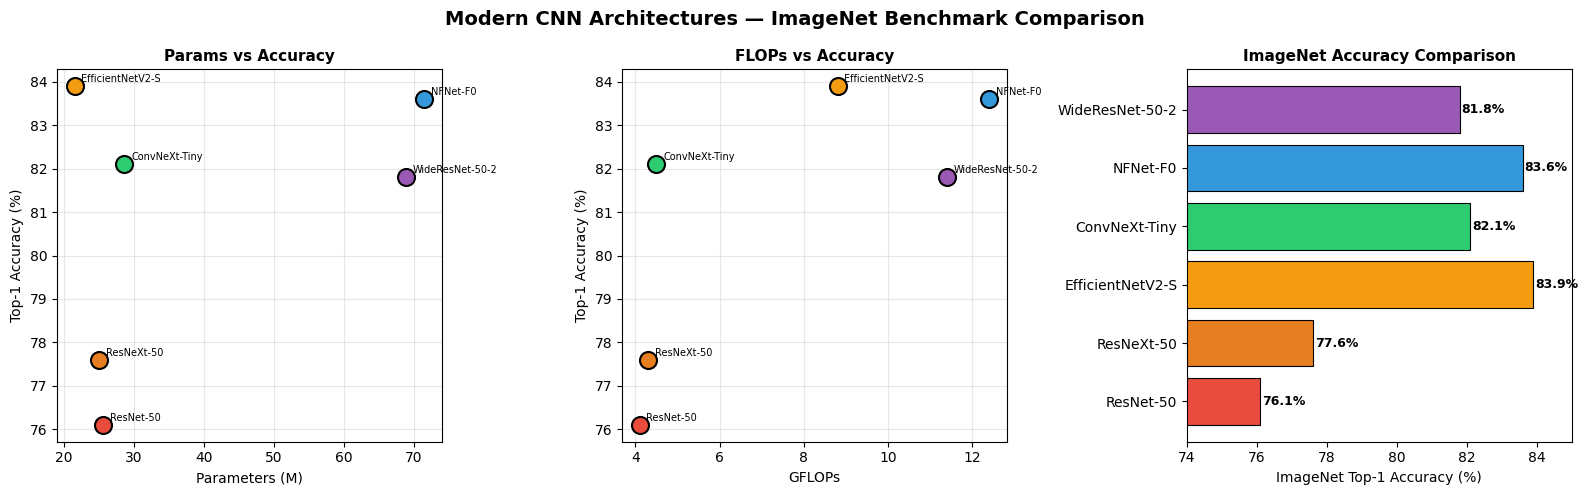

In [ ]:
# ── Final Summary: Architecture Comparison Dashboard ─────────────────────────
arch_data = {
    'Architecture': ['ResNet-50', 'ResNeXt-50 (32×4d)', 'EfficientNetV2-S',
                     'ConvNeXt-Tiny', 'NFNet-F0', 'WideResNet-50-2'],
    'Params (M)':   [25.6, 25.0, 21.5, 28.6, 71.5, 68.9],
    'GFLOPs':       [4.1, 4.3, 8.8, 4.5, 12.4, 11.4],
    'Top-1 Acc':    [76.1, 77.6, 83.9, 82.1, 83.6, 81.8],
    'BatchNorm':    ['Yes', 'Yes', 'Yes', 'Yes', 'NO', 'Yes'],
    'Attention':    ['No', 'No', 'SE', 'No', 'No', 'No'],
    'Year':         [2015, 2017, 2021, 2022, 2021, 2016]
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#E74C3C','#E67E22','#F39C12','#2ECC71','#3498DB','#9B59B6']
names = arch_data['Architecture']

# Plot 1: Params vs Accuracy
for i, (p, a, n) in enumerate(zip(arch_data['Params (M)'], arch_data['Top-1 Acc'], names)):
    axes[0].scatter(p, a, s=150, color=colors[i], zorder=5, edgecolors='k', lw=1.5)
    axes[0].annotate(n.split()[0], (p, a), textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[0].set_xlabel('Parameters (M)', fontsize=10)
axes[0].set_ylabel('Top-1 Accuracy (%)', fontsize=10)
axes[0].set_title('Params vs Accuracy', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: FLOPs vs Accuracy
for i, (f, a, n) in enumerate(zip(arch_data['GFLOPs'], arch_data['Top-1 Acc'], names)):
    axes[1].scatter(f, a, s=150, color=colors[i], zorder=5, edgecolors='k', lw=1.5)
    axes[1].annotate(n.split()[0], (f, a), textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[1].set_xlabel('GFLOPs', fontsize=10)
axes[1].set_ylabel('Top-1 Accuracy (%)', fontsize=10)
axes[1].set_title('FLOPs vs Accuracy', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Accuracy bar chart
short_names = [n.split()[0] for n in names]
bars = axes[2].barh(short_names, arch_data['Top-1 Acc'],
                    color=colors, edgecolor='k', linewidth=0.8)
axes[2].set_xlabel('ImageNet Top-1 Accuracy (%)', fontsize=10)
axes[2].set_title('ImageNet Accuracy Comparison', fontsize=11, fontweight='bold')
axes[2].set_xlim(74, 85)
for bar, acc in zip(bars, arch_data['Top-1 Acc']):
    axes[2].text(acc + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{acc}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Modern CNN Architectures — ImageNet Benchmark Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('architecture_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📚 Summary

| Topic | Key Takeaway |
|---|---|
| **ConvNeXt** | ViT design choices (GELU, LayerNorm, 7×7 DWConv) applied to pure CNNs |
| **EfficientNetV2** | Fused-MBConv + progressive learning = faster training, same accuracy |
| **NFNet** | No BatchNorm needed — Weight Standardization + AGC achieves SOTA |
| **ResNeXt / WRN** | Cardinality and width as orthogonal scaling axes to depth |
| **YOLO v8-v10** | Anchor-free, decoupled head, NMS-free → real-time edge deployment |
| **Mask R-CNN** | RoIAlign → pixel-accurate instance segmentation |
| **EfficientDet** | BiFPN with learnable weights = best multi-scale feature fusion |
| **SE / CBAM** | Channel + spatial attention → small overhead, meaningful gains |
| **1D CNNs** | Same CNN principles apply to temporal/signal data |
| **Transfer Learning** | Always start from pretrained weights; use differential LR |

---

### 🔗 References
- Sergey Ioffe (2015). [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/pdf/1502.03167)
- Wu & He (2018). [Group Normalization](https://arxiv.org/pdf/1803.08494) — ECCV; discusses small-batch limits of BN and GN’s channel-group statistics.
- Liu et al. (2022). [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545)
- Woo et al. (2023). [ConvNeXt V2: Co-designing and Scaling ConvNets with Masked Autoencoders](https://arxiv.org/pdf/2301.00808)
- Tan & Le (2021). [EfficientNetV2: Smaller Models and Faster Training](https://arxiv.org/abs/2104.00298)
- Brock et al. (2021). [High-Performance Large-Scale Image Recognition Without Normalization](https://arxiv.org/abs/2102.06171)
- Xie et al. (2017). [Aggregated Residual Transformations for Deep Neural Networks (ResNeXt)](https://arxiv.org/abs/1611.05431)
- Ren et al. (2015). [Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks](https://arxiv.org/abs/1506.01497)
- He et al. (2017). [Mask R-CNN](https://arxiv.org/abs/1703.06870)
- Tan et al. (2020). [EfficientDet: Scalable and Efficient Object Detection](https://arxiv.org/abs/1911.09070)
- Hu et al. (2018). [Squeeze-and-Excitation Networks](https://arxiv.org/abs/1709.01507)
- Woo et al. (2018). [CBAM: Convolutional Block Attention Module](https://arxiv.org/abs/1807.06521)
- Li, J.; Wu (2024). [FSNB-YOLOV8: Improvement of Object Detection Model for
Surface Defects Inspection in Online Industrial Systems](https://pdfs.semanticscholar.org/d27e/527d922d831fd791fc9345d07e2ea521564a.pdf)